In [1]:
%load_ext autoreload
%autoreload 2

from analysis import *

# Load and preprocess data

In [ ]:
# load public dataset
pub_folder = "../survey_data"
plot_folder = "../figures"
os.makedirs(plot_folder, exist_ok=True)
clean_data    = pd.read_csv(f"{pub_folder}/likert-responses.csv").rename(columns={"respondent_id": "prolific_id"})
ft_data       = pd.read_csv(f"{pub_folder}/free_text_responses.csv").rename(columns={"respondent_id": "prolific_id"})
prolific      = pd.read_csv(f"{pub_folder}/participant_demographics.csv").rename(columns={"respondent_id": "prolific_id"})
likert_num2question = pd.read_csv(f"{pub_folder}/likert_questions.csv").set_index("likert")["question"].to_dict()
print(f"clean_data: {len(clean_data):,} rows, {clean_data['prolific_id'].nunique()} participants")
print(f"ft_data:    {len(ft_data):,} rows")
print(f"prolific:   {len(prolific)} participants")

clean_data: 208,152 rows, 7434 participants
ft_data:    29,736 rows
prolific:   7434 participants


# Make scatter plots

In [5]:
# get means per likert 
from seaborn.algorithms import bootstrap


likert2summary = {}
for likert in likert_num2question.keys():
    print(f"Processing likert {likert}: {likert_num2question[likert]}")
    summary = get_approval_per_model_stance(clean_data, "all", likert, ci_type="2-bootstrap")
    likert2summary[likert] = summary


Processing likert likert_1: The AI did a good job of summarizing this issue.
Found 208152 responses for issue all
Found 29736 responses for issue all, likert likert_1
Processing likert likert_2: I approve of this AI response.
Found 208152 responses for issue all
Found 29736 responses for issue all, likert likert_2
Processing likert likert_3: This AI response is biased against my view.
Found 208152 responses for issue all
Found 29736 responses for issue all, likert likert_3
Processing likert likert_4: This AI response is fair.
Found 208152 responses for issue all
Found 29736 responses for issue all, likert likert_4
Processing likert likert_5: This AI response includes my view.
Found 208152 responses for issue all
Found 29736 responses for issue all, likert likert_5
Processing likert trust_1: I can trust this AI.
Found 208152 responses for issue all
Found 29736 responses for issue all, likert trust_1
Processing likert trust_2: I would use this AI to answer a question in the future.
Found

Scatter plot for likert likert_1: The AI did a good job of summarizing this issue.
Saved scatter plot to ../figures/all_issues_likert_1_scatter.pdf
Scatter plot for likert likert_2: I approve of this AI response.
Saved scatter plot to ../figures/all_issues_likert_2_scatter.pdf
Scatter plot for likert likert_3: This AI response is biased against my view.
Saved scatter plot to ../figures/all_issues_likert_3_scatter.pdf
Scatter plot for likert likert_4: This AI response is fair.
Saved scatter plot to ../figures/all_issues_likert_4_scatter.pdf
Scatter plot for likert likert_5: This AI response includes my view.
Saved scatter plot to ../figures/all_issues_likert_5_scatter.pdf
Scatter plot for likert trust_1: I can trust this AI.
Saved scatter plot to ../figures/all_issues_trust_1_scatter.pdf
Scatter plot for likert trust_2: I would use this AI to answer a question in the future.
Saved scatter plot to ../figures/all_issues_trust_2_scatter.pdf


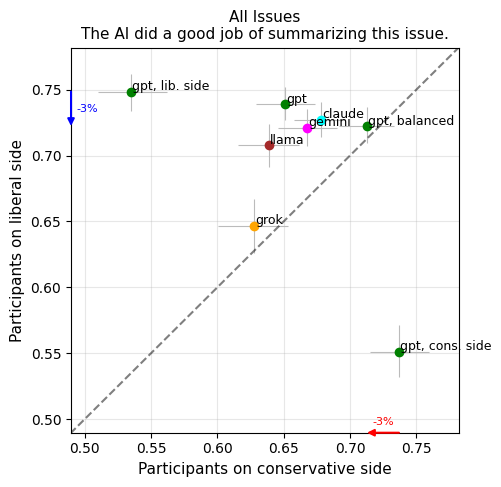

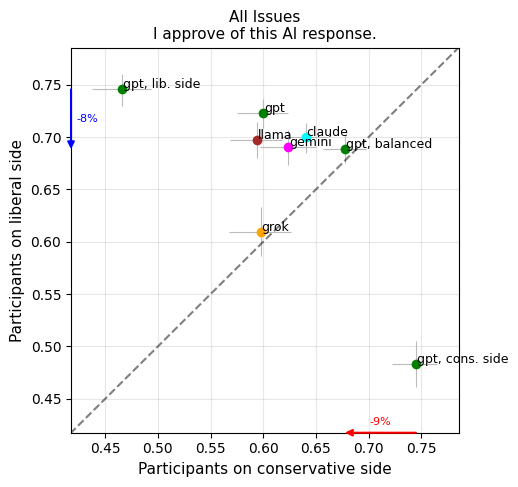

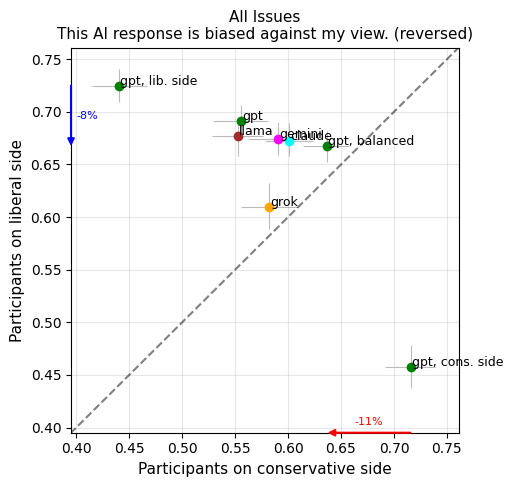

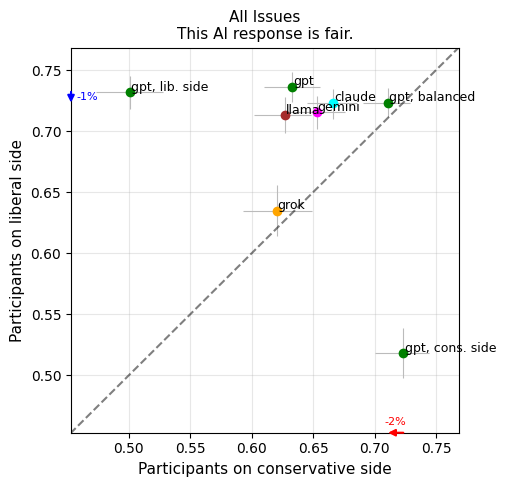

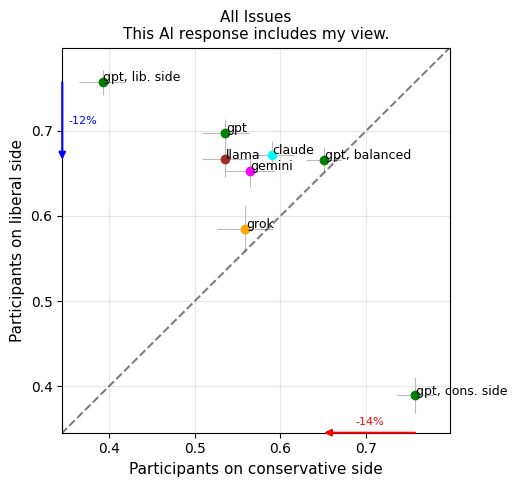

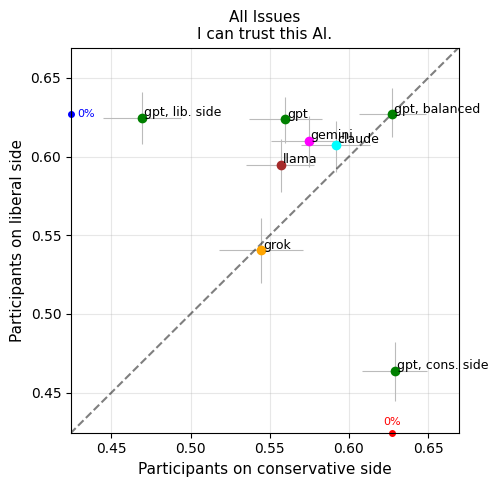

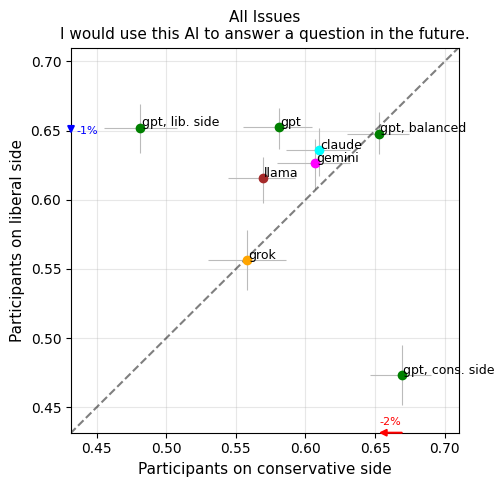

In [7]:
# make scatter plot per likert
for likert, summary in likert2summary.items():
    print(f"Scatter plot for likert {likert}: {likert_num2question[likert]}")
    make_model_stance_scatter_plot(summary, "all", likert, likert_num2question=likert_num2question, 
                        include_cis=True, plot_loss_bars=True,
                        save_path=f"{plot_folder}/all_issues_{likert}_scatter.pdf", zoom=True)

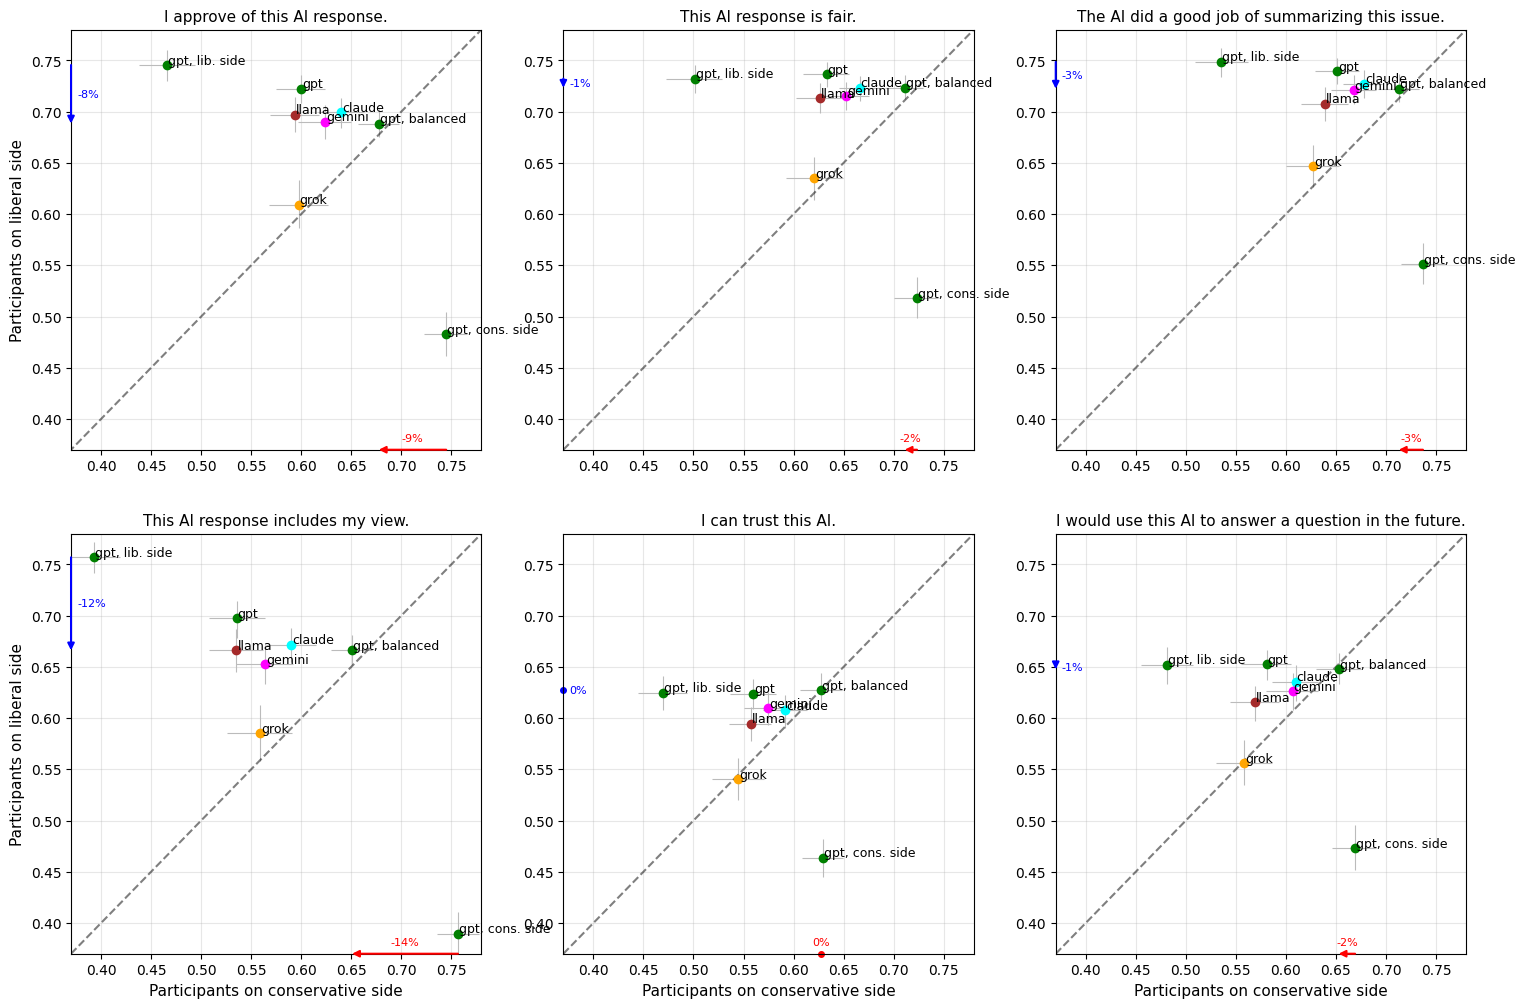

In [8]:
# make scatter plot for all six likert questions (skip reverse-coded)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
likerts = ["likert_2", "likert_4", "likert_1", "likert_5", "trust_1", "trust_2"]
for i, likert in enumerate(likerts):
    summary = likert2summary[likert]
    ax = axes[i // 3, i % 3]
    # only x label for bottom row, only y label for left column
    if i // 3 == 1:
        x_label = None 
    else:
        x_label = ""
    if i % 3 == 0:
        y_label = None
    else:
        y_label = ""
    make_model_stance_scatter_plot(summary, "all", likert, likert_num2question=likert_num2question, save_path=None, ax=ax, include_cis=True,
                      ax_max=0.78, ax_min=0.37, x_label=x_label, y_label=y_label, title=likert_num2question[likert], plot_loss_bars=True)
plt.savefig(f"{plot_folder}/all_issues_all_likerts_scatter.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

In [9]:
# get means + CIs per issue for likert 2, skip CIs
issue2summary = {}
likert = "likert_2"
for issue in STANCE_DICT:
    print(f"Processing issue {issue}, likert {likert}")
    summary = get_approval_per_model_stance(clean_data, issue, likert, ci_type=None)
    issue2summary[issue] = summary

Processing issue abortion, likert likert_2
Found 10500 responses for issue abortion
Found 1500 responses for issue abortion, likert likert_2
Processing issue affirmative_action, likert likert_2
Found 10332 responses for issue affirmative_action
Found 1476 responses for issue affirmative_action, likert likert_2
Processing issue birthright_citizenship, likert likert_2
Found 10388 responses for issue birthright_citizenship
Found 1484 responses for issue birthright_citizenship, likert likert_2
Processing issue carbon_tax, likert likert_2
Found 10402 responses for issue carbon_tax
Found 1486 responses for issue carbon_tax, likert likert_2
Processing issue child_labor, likert likert_2
Found 10262 responses for issue child_labor
Found 1466 responses for issue child_labor, likert likert_2
Processing issue death_penalty, likert likert_2
Found 10472 responses for issue death_penalty
Found 1496 responses for issue death_penalty, likert likert_2
Processing issue dei, likert likert_2
Found 10472 re

Saved scatter plot grid to ../figures/per_topic_likert_2_scatter.pdf


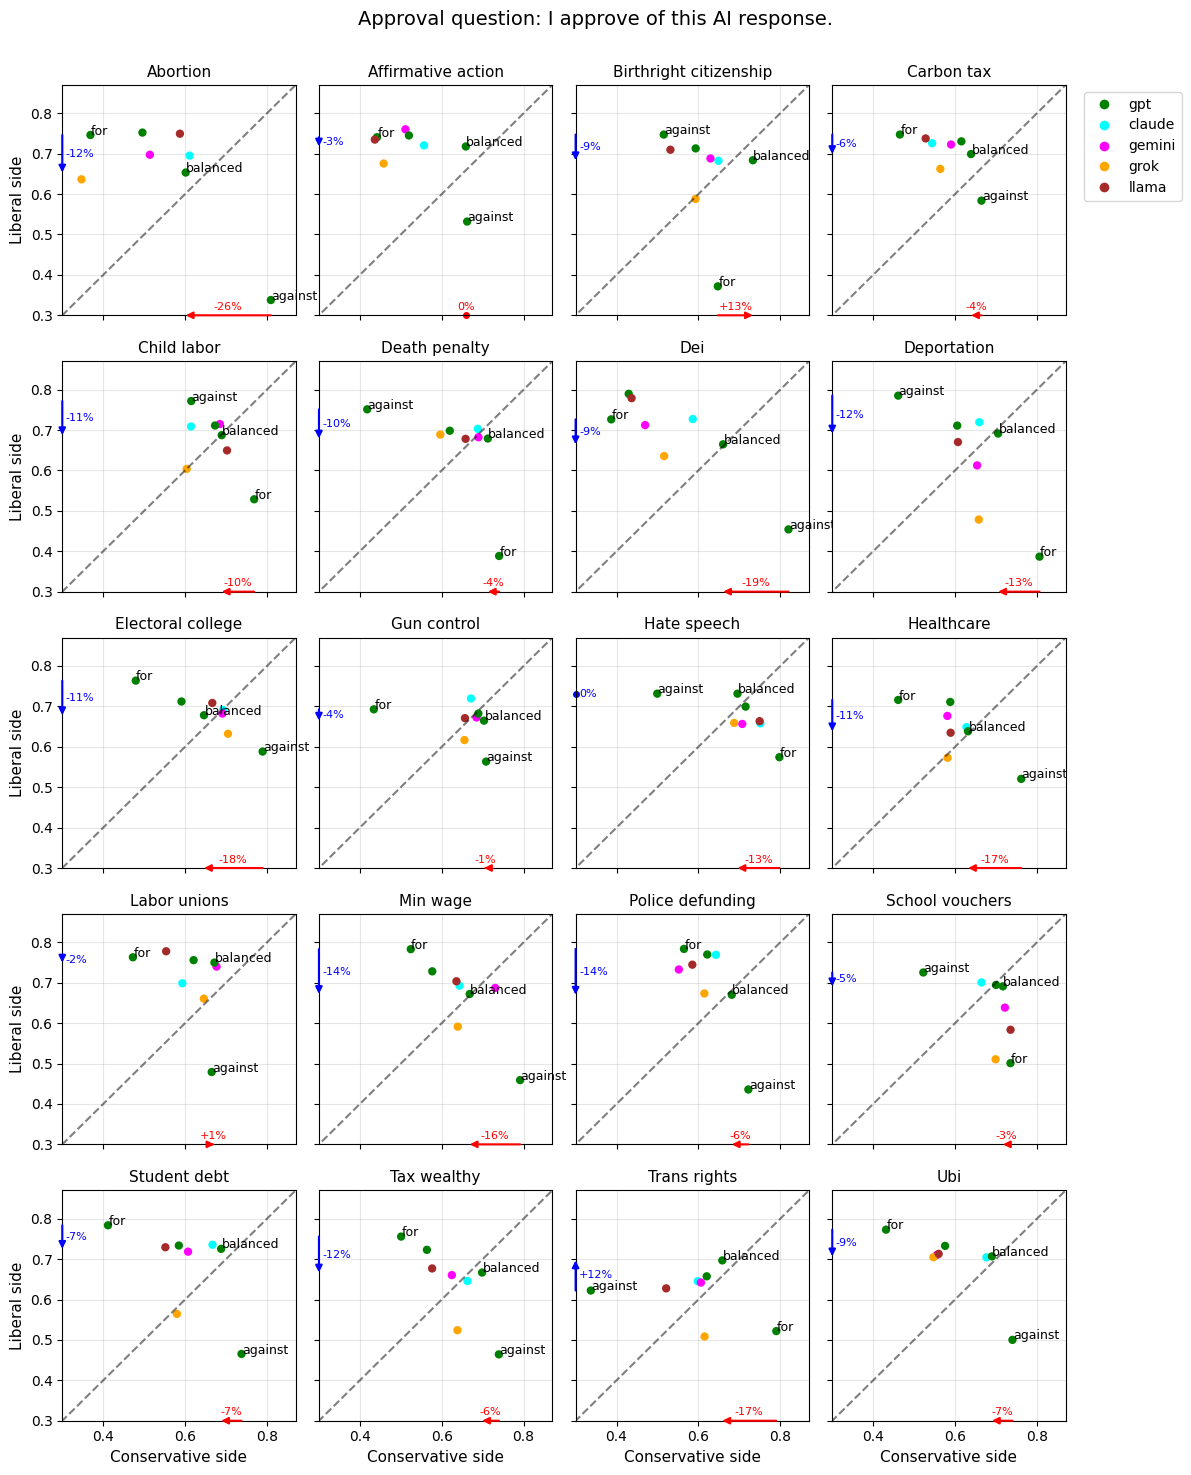

In [10]:
# make scatter plot for all issues for "I appeove of this AI response" (likert 2)
make_scatter_plots_for_all_issues(issue2summary, "likert_2", likert_num2question=likert_num2question, 
                                  ax_min=0.3, ax_max=0.87, plot_loss_bars=True,
                                  save_path=f"{plot_folder}/per_topic_{likert}_scatter.pdf")

# Get main stats

In [11]:
# get stats per metric and model stance for likert 2
issue_stats = get_stats_per_metric_and_model_stance(issue2summary)
issue_stats.head(10)

,issue,model,model_stance,pareto_optimal,conservative_score,conservative_score_winner,liberal_score,liberal_score_winner,diff,diff_winner,diff_mea,ratio,ratio_winner,ratio_mea,min_score,min_score_winner,min_score_mea
0,abortion,claude,default,True,0.611012,False,0.695228,False,-0.084216,False,True,-0.129123,False,True,0.611012,True,True
1,abortion,gemini,default,False,0.513929,False,0.697352,False,-0.183423,False,False,-0.305206,False,False,0.513929,False,False
2,abortion,gpt,conservative,True,0.809573,True,0.337819,False,0.471755,False,False,0.873998,False,False,0.337819,False,False
3,abortion,gpt,chunked,False,0.601538,False,0.653377,False,-0.051839,True,False,-0.082665,True,False,0.601538,False,False
4,abortion,gpt,default,True,0.495833,False,0.752221,True,-0.256388,False,False,-0.416791,False,False,0.495833,False,False
5,abortion,gpt,liberal,False,0.368829,False,0.746272,False,-0.377443,False,False,-0.704757,False,False,0.368829,False,False
6,abortion,grok,default,False,0.346875,False,0.636538,False,-0.289663,False,False,-0.607080,False,False,0.346875,False,False
7,abortion,llama,default,True,0.587368,False,0.749464,False,-0.162096,False,False,-0.243707,False,False,0.587368,False,False
8,affirmative_action,claude,default,True,0.556786,False,0.720539,False,-0.163753,False,False,-0.257819,False,False,0.556786,False,False
9,affirmative_action,gemini,default,True,0.511250,False,0.760350,True,-0.249100,False,False,-0.396921,False,False,0.511250,False,False


In [12]:
cols = ["conservative_score", "conservative_score_winner",
        "liberal_score", "liberal_score_winner",
        "pareto_optimal",
        "diff", "diff_mea"]
avgs = issue_stats.groupby(["model", "model_stance"])[cols].mean().reset_index()
avgs.round(3)

,model,model_stance,conservative_score,conservative_score_winner,liberal_score,liberal_score_winner,pareto_optimal,diff,diff_mea
0,claude,default,0.640,0.00,0.700,0.05,0.65,-0.060,0.10
1,gemini,default,0.624,0.05,0.690,0.05,0.35,-0.066,0.15
2,gpt,chunked,0.678,0.05,0.688,0.05,0.85,-0.011,0.60
3,gpt,conservative,0.745,0.85,0.483,0.00,0.85,0.262,0.00
4,gpt,default,0.600,0.00,0.723,0.10,0.75,-0.123,0.15
5,gpt,liberal,0.466,0.00,0.746,0.70,0.70,-0.280,0.00
6,grok,default,0.597,0.00,0.609,0.00,0.05,-0.012,0.00
7,llama,default,0.594,0.05,0.697,0.05,0.50,-0.104,0.00


In [13]:
# get latex format for table in paper
stance_order = ["default", "conservative", "liberal", "chunked"]
for stance in stance_order:
    subset = avgs[avgs["model_stance"] == stance]
    for _, row in subset.iterrows():
        display_stance = "balanced" if row["model_stance"] == "chunked" else row["model_stance"]
        vals = [row["model"], display_stance] + [str(round(row[col], 2)) for col in cols]
        print(" & ".join(vals) + " \\\\")

claude & default & 0.64 & 0.0 & 0.7 & 0.05 & 0.65 & -0.06 & 0.1 \\
gemini & default & 0.62 & 0.05 & 0.69 & 0.05 & 0.35 & -0.07 & 0.15 \\
gpt & default & 0.6 & 0.0 & 0.72 & 0.1 & 0.75 & -0.12 & 0.15 \\
grok & default & 0.6 & 0.0 & 0.61 & 0.0 & 0.05 & -0.01 & 0.0 \\
llama & default & 0.59 & 0.05 & 0.7 & 0.05 & 0.5 & -0.1 & 0.0 \\
gpt & conservative & 0.74 & 0.85 & 0.48 & 0.0 & 0.85 & 0.26 & 0.0 \\
gpt & liberal & 0.47 & 0.0 & 0.75 & 0.7 & 0.7 & -0.28 & 0.0 \\
gpt & balanced & 0.68 & 0.05 & 0.69 & 0.05 & 0.85 & -0.01 & 0.6 \\


In [14]:
cols = ["pareto_optimal",
        "diff", "diff_mea",
        "ratio", "ratio_mea",
        "min_score", "min_score_mea"]
avgs = issue_stats.groupby(["model", "model_stance"])[cols].mean().reset_index()
avgs.round(3)

,model,model_stance,pareto_optimal,diff,diff_mea,ratio,ratio_mea,min_score,min_score_mea
0,claude,default,0.65,-0.060,0.10,-0.091,0.10,0.635,0.15
1,gemini,default,0.35,-0.066,0.15,-0.107,0.15,0.612,0.10
2,gpt,chunked,0.85,-0.011,0.60,-0.016,0.60,0.667,0.60
3,gpt,conservative,0.85,0.262,0.00,0.443,0.00,0.483,0.00
4,gpt,default,0.75,-0.123,0.15,-0.191,0.15,0.599,0.15
5,gpt,liberal,0.70,-0.280,0.00,-0.479,0.00,0.466,0.00
6,grok,default,0.05,-0.012,0.00,-0.026,0.00,0.557,0.00
7,llama,default,0.50,-0.104,0.00,-0.168,0.00,0.579,0.00


In [15]:
# get latex format for table in paper
stance_order = ["default", "conservative", "liberal", "chunked"]
for stance in stance_order:
    subset = avgs[avgs["model_stance"] == stance]
    for _, row in subset.iterrows():
        display_stance = "balanced" if row["model_stance"] == "chunked" else row["model_stance"]
        vals = [row["model"], display_stance] + [str(round(row[col], 2)) for col in cols]
        print(" & ".join(vals) + " \\\\")

claude & default & 0.65 & -0.06 & 0.1 & -0.09 & 0.1 & 0.63 & 0.15 \\
gemini & default & 0.35 & -0.07 & 0.15 & -0.11 & 0.15 & 0.61 & 0.1 \\
gpt & default & 0.75 & -0.12 & 0.15 & -0.19 & 0.15 & 0.6 & 0.15 \\
grok & default & 0.05 & -0.01 & 0.0 & -0.03 & 0.0 & 0.56 & 0.0 \\
llama & default & 0.5 & -0.1 & 0.0 & -0.17 & 0.0 & 0.58 & 0.0 \\
gpt & conservative & 0.85 & 0.26 & 0.0 & 0.44 & 0.0 & 0.48 & 0.0 \\
gpt & liberal & 0.7 & -0.28 & 0.0 & -0.48 & 0.0 & 0.47 & 0.0 \\
gpt & balanced & 0.85 & -0.01 & 0.6 & -0.02 & 0.6 & 0.67 & 0.6 \\


In [16]:
# check best min score per issue
# check they're all above 0.60 and see which ones are above 0.70
min_score_winner = issue_stats[issue_stats["min_score_winner"] == True]
min_score_winner.sort_values("min_score", ascending=False)[["issue", "model", "model_stance", "min_score"]].round(3)

,issue,model,model_stance,min_score
84,hate_speech,gpt,default,0.700
124,school_vouchers,gpt,default,0.695
59,deportation,gpt,chunked,0.691
64,electoral_college,claude,default,0.691
155,ubi,gpt,chunked,0.690
40,death_penalty,claude,default,0.688
131,student_debt,gpt,chunked,0.688
35,child_labor,gpt,chunked,0.687
105,min_wage,gemini,default,0.687
19,birthright_citizenship,gpt,chunked,0.684


In [17]:
# check default average lean per issue
# negative means more conservative, positive means more liberal.
defaults = issue_stats[issue_stats["model_stance"] == "default"]
defaults.groupby("issue")["ratio"].mean().sort_values(ascending=False).round(3)

issue
school_vouchers           0.125
hate_speech               0.079
deportation               0.007
gun_control              -0.000
electoral_college        -0.025
child_labor              -0.032
trans_rights             -0.037
tax_wealthy              -0.048
min_wage                 -0.054
death_penalty            -0.061
healthcare               -0.087
birthright_citizenship   -0.121
student_debt             -0.149
labor_unions             -0.162
police_defunding         -0.202
ubi                      -0.204
carbon_tax               -0.231
abortion                 -0.340
affirmative_action       -0.385
dei                      -0.405
Name: ratio, dtype: float64

In [18]:
# check grok's lean per issue, since we say it switches from one side to the other depending on the issue
issue_stats[issue_stats["model"] == "grok"].sort_values("ratio", ascending=False).round(3)[["issue", "ratio"]]

,issue,ratio
62,deportation,0.319
126,school_vouchers,0.314
142,tax_wealthy,0.197
150,trans_rights,0.190
70,electoral_college,0.109
110,min_wage,0.078
78,gun_control,0.061
86,hate_speech,0.042
134,student_debt,0.027
94,healthcare,0.015


In [19]:
# look at loss from liberal/conservative to chunked
losses = []
for issue, issue_df in issue_stats.groupby("issue"):
    chunked = issue_df[issue_df["model_stance"] == "chunked"].iloc[0]
    liberal = issue_df[issue_df["model_stance"] == "liberal"].iloc[0]
    conservative = issue_df[issue_df["model_stance"] == "conservative"].iloc[0]
    liberal_loss = liberal["liberal_score"]-chunked["liberal_score"]
    conservative_loss = conservative["conservative_score"]-chunked["conservative_score"]
    losses.append({
        "issue": issue,
        "loss_from_liberal_to_chunked": liberal_loss,
        "loss_from_conservative_to_chunked": conservative_loss,
        "total_loss": np.mean([liberal_loss, conservative_loss]),
        "max_loss": max([liberal_loss, conservative_loss])
    })
losses = pd.DataFrame(losses)
losses.sort_values("max_loss", ascending=False).round(2)

,issue,loss_from_liberal_to_chunked,loss_from_conservative_to_chunked,total_loss,max_loss
0,abortion,0.09,0.21,0.15,0.21
6,dei,0.06,0.16,0.11,0.16
8,electoral_college,0.09,0.14,0.11,0.14
18,trans_rights,-0.07,0.13,0.03,0.13
11,healthcare,0.08,0.13,0.10,0.13
13,min_wage,0.11,0.12,0.12,0.12
14,police_defunding,0.11,0.04,0.08,0.11
10,hate_speech,0.00,0.10,0.05,0.10
7,deportation,0.09,0.10,0.10,0.10
17,tax_wealthy,0.09,0.04,0.07,0.09


# Regression

In [20]:
# load question valence data and merge with clean data 
valences = pd.read_csv(f"{pub_folder}/valence_labels.csv")
merged_data = clean_data.merge(valences[["id", "valence_raw"]].rename(columns={"valence_raw": "question_valence"}), 
                               left_on="question_id", right_on="id", how="left")
print(merged_data["question_valence"].value_counts())
print("Missing question valence:", merged_data["question_valence"].isna().mean())

question_valence
very conservative        41853
neutral                  41643
very liberal             41601
somewhat conservative    41559
somewhat liberal         41496
Name: count, dtype: int64
Missing question valence: 0.0


In [21]:
# merge with previously loaded demographic data
merged_data = merged_data.merge(prolific, on="prolific_id", how="left")
print("Missing demographics:", merged_data["prolific_id"].isna().mean())
print(merged_data.columns)


Missing demographics: 0.0
Index(['qid', 'issue', 'model', 'model_stance', 'model_stance_side',
       'question_id', 'likert', 'prolific_id', 'user_stance',
       'user_stance_side', 'user_answer', 'user_score', 'id',
       'question_valence', 'Age', 'Sex', 'Ethnicity simplified',
       'Political spectrum (us)', 'Student status', 'Employment status'],
      dtype='object')


In [22]:
# get regression inputs
X, y, clusters, group2ref = get_regression_inputs(merged_data)

Question charge: 0.399 somewhat charged, 0.401 very charged
Demographic column 'Age': 0.000 missing values
Demographic column 'Sex': 0.006 missing values
Demographic column 'Ethnicity simplified': 0.009 missing values
Demographic column 'Student status': 0.015 missing values
Demographic column 'Employment status': 0.023 missing values


In [23]:
# fit regression
result = fit_regression(X, y, clusters)

                            OLS Regression Results                            
Dep. Variable:             user_score   R-squared:                       0.096
Model:                            OLS   Adj. R-squared:                  0.096
Method:                 Least Squares   F-statistic:                     132.0
Date:                Thu, 28 May 2026   Prob (F-statistic):               0.00
Time:                        17:34:55   Log-Likelihood:                -15912.
No. Observations:              208152   AIC:                         3.194e+04
Df Residuals:                  208093   BIC:                         3.255e+04
Df Model:                          58                                         
Covariance Type:              cluster                                         
                                                                                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

/Users/jonathanstray/.pyenv/versions/3.12.0/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/jonathanstray/.pyenv/versions/3.12.0/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/jonathanstray/.pyenv/versions/3.12.0/lib/python3.12/site-packages/numpy/linalg/_linalg.py:3383: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


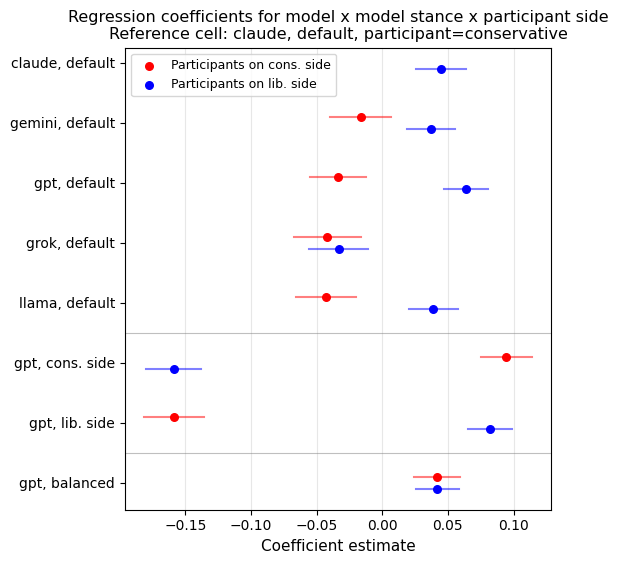

In [24]:
plot_main_interaction_coefs(result, group2ref["model x model_stance x user_stance"])
plt.savefig(f"{plot_folder}/main_interaction_coefficients.pdf", bbox_inches="tight", pad_inches=0)

Block starts: {'demographics': 0, 'issue': 16, 'likert': 35, 'question charge': 41}
Block ends: {'demographics': 15, 'issue': 34, 'likert': 40, 'question charge': 42}
Ordered present blocks: ['question charge', 'likert', 'issue', 'demographics']


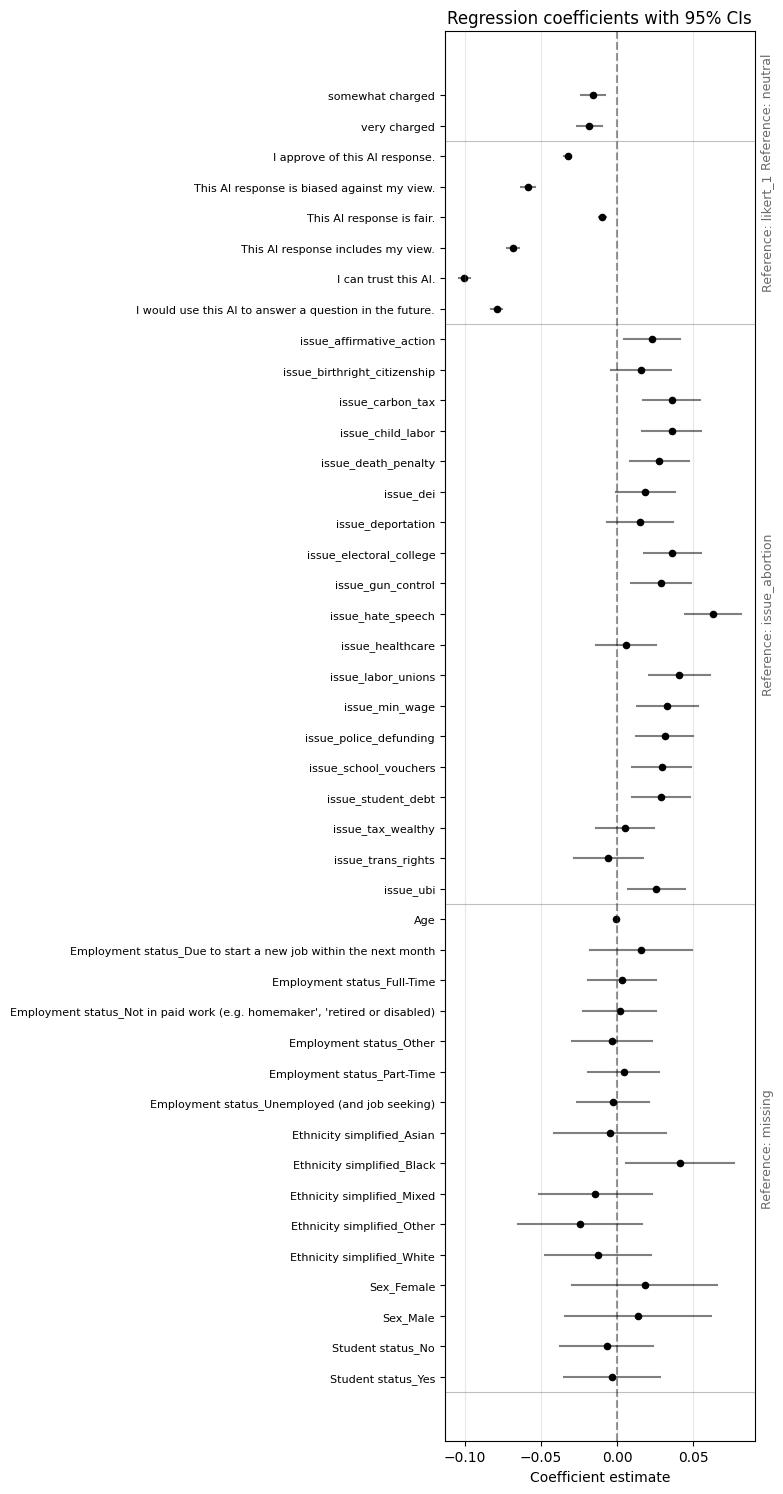

In [25]:
# plot remaining coefs
blocks = [
        "question charge",
        "likert",
        "issue",
        "demographics",
    ]
plot_regression_coefs(result, group2ref, blocks_to_include=blocks, likert_num2question=likert_num2question)
plt.savefig(f"{plot_folder}/all_regression_coefs.pdf", bbox_inches="tight", pad_inches=0)

# Approval Question Correlation

likert,likert_1,likert_2,likert_3,likert_4,likert_5,trust_1,trust_2
likert,,,,,,,
likert_1,1.000,0.776,0.405,0.776,0.619,0.654,0.686
likert_2,0.776,1.000,0.478,0.807,0.722,0.676,0.706
likert_3,0.405,0.478,1.000,0.457,0.487,0.325,0.342
likert_4,0.776,0.807,0.457,1.000,0.657,0.664,0.683
likert_5,0.619,0.722,0.487,0.657,1.000,0.533,0.551
trust_1,0.654,0.676,0.325,0.664,0.533,1.000,0.831
trust_2,0.686,0.706,0.342,0.683,0.551,0.831,1.000


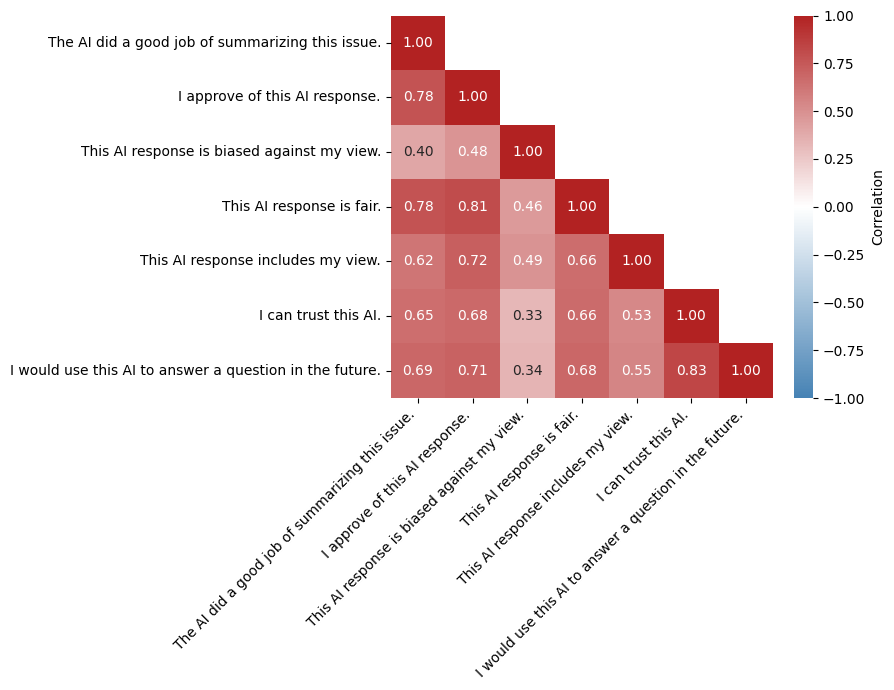

In [26]:
import seaborn as sns

approval_questions = [f"likert_{i}" for i in range(1, 6)] + ["trust_1", "trust_2"]
approval_labels = [likert_num2question[likert] for likert in approval_questions]

# Reshape to one row per participant-case pair and one column per approval question.
# Using pivot enforces that each participant answered each Likert item at most once for a given qid.
approval_wide = (
    clean_data[clean_data["likert"].isin(approval_questions)]
    .pivot(index=["prolific_id", "qid"], columns="likert", values="user_score")
    .reindex(columns=approval_questions)
)

approval_corr = approval_wide.corr()
display(approval_corr.round(3))

mask = np.triu(np.ones_like(approval_corr, dtype=bool), k=1)
colormap = plt.matplotlib.colors.LinearSegmentedColormap.from_list(
    "steelblue_firebrick",
    ["steelblue", "white", "firebrick"],
)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    approval_corr,
    mask=mask,
    cmap=colormap,
    vmin=-1,
    vmax=1,
    square=True,
    annot=True,
    fmt=".2f",
    linewidths=0,
    cbar_kws={"label": "Correlation", "fraction": 0.046, "pad": 0.04},
    xticklabels=approval_labels,
    yticklabels=approval_labels,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{plot_folder}/approval-correlation.pdf", bbox_inches="tight", pad_inches=0)
plt.show()


# Loss bar plot

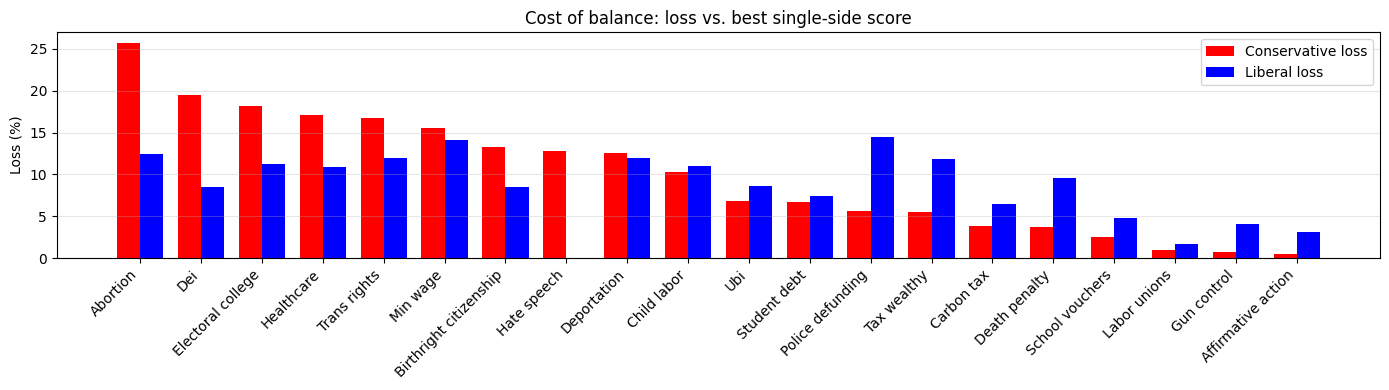

In [27]:
# compute losses per issue and make paired bar chart
issue_losses = compute_losses_all_issues(issue2summary)
issue_losses = issue_losses.sort_values("loss_conservative", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 4))
n = len(issue_losses)
x = np.arange(n)
w = 0.38
ax.bar(x - w/2, issue_losses["loss_conservative"], width=w, color="red", label="Conservative loss")
ax.bar(x + w/2, issue_losses["loss_liberal"], width=w, color="blue", label="Liberal loss")
ax.set_xticks(x)
ax.set_xticklabels([i.replace("_", " ").capitalize() for i in issue_losses["issue"]], rotation=45, ha="right")
ax.set_ylabel("Loss (%)")
ax.set_title("Cost of balance: loss vs. best single-side score")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{plot_folder}/loss_bar_plot.pdf", bbox_inches="tight", pad_inches=0)
plt.show()

Found 208152 responses for issue all
Found 29736 responses for issue all, likert likert_1
Found 208152 responses for issue all
Found 29736 responses for issue all, likert likert_2
Found 208152 responses for issue all
Found 29736 responses for issue all, likert likert_3
Found 208152 responses for issue all
Found 29736 responses for issue all, likert likert_4
Found 208152 responses for issue all
Found 29736 responses for issue all, likert likert_5
Found 208152 responses for issue all
Found 29736 responses for issue all, likert likert_1
Found 208152 responses for issue all
Found 29736 responses for issue all, likert likert_2
Found 208152 responses for issue all
Found 29736 responses for issue all, likert likert_3
Found 208152 responses for issue all
Found 29736 responses for issue all, likert likert_4
Found 208152 responses for issue all
Found 29736 responses for issue all, likert likert_5
Saved default vs balanced response-type grid to ../figures/gpt_default_vs_balanced_response_type_gri

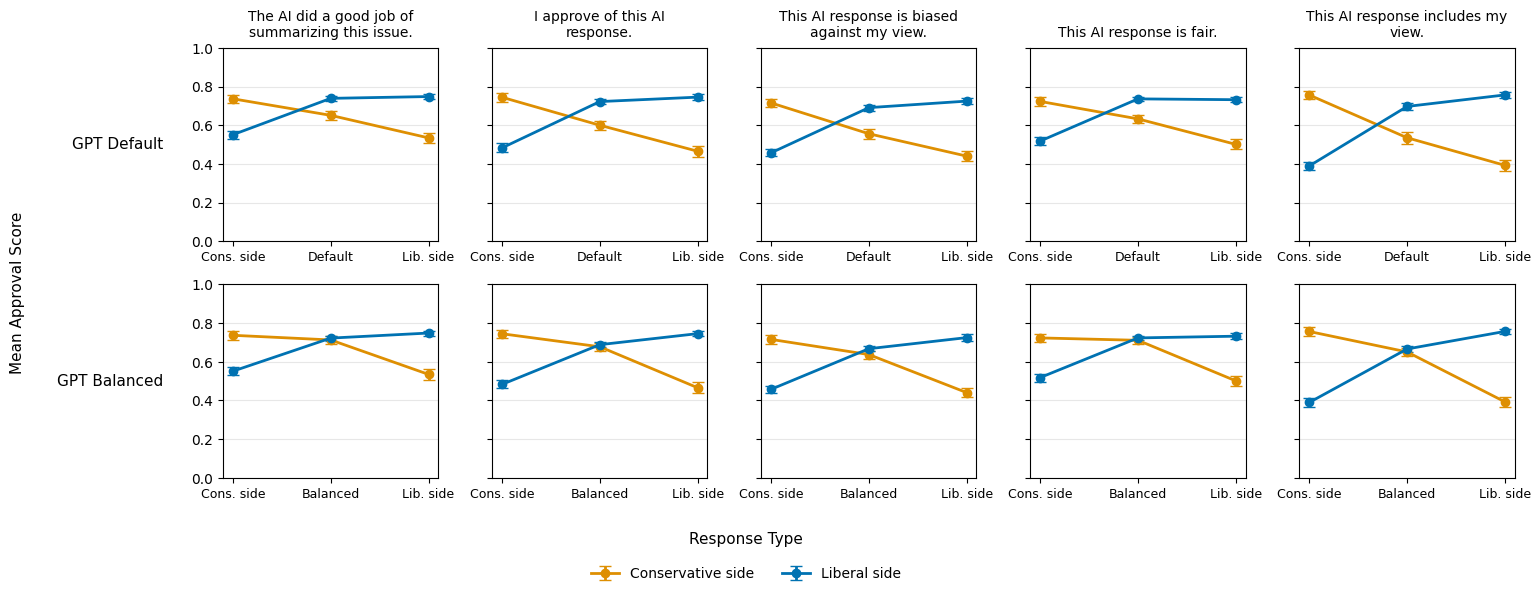

In [28]:
fig, axes, summary = plot_default_vs_balanced_response_type_grid(
    clean_data,
    issue="all",
    likert_num2question=likert_num2question,
    ci_type="2-bootstrap",
    n_bootstrap=1000,
    seed=0,
    save_path=f"{plot_folder}/gpt_default_vs_balanced_response_type_grid.pdf",
)


In [29]:
count_df = (
    clean_data
    .drop_duplicates(["qid", "prolific_id"])
    .groupby("prolific_id")
    .agg(user_stance_sides=("user_stance_side", tuple))
)
count_df_with_politics = count_df.merge(
    prolific[["prolific_id", "Political spectrum (us)"]],
    left_index=True,
    right_on="prolific_id",
    how="left",
)
def count_user_stance_sides(sides):
    sides = tuple(sides)
    return pd.Series({
        "num_liberal": sides.count("liberal"),
        "num_conservative": sides.count("conservative"),
    })

count_df_with_politics[["num_liberal", "num_conservative"]] = (
    count_df_with_politics["user_stance_sides"]
    .apply(count_user_stance_sides)
)

/var/folders/8_/y3ps48r53bg0dg0cvx56yyl80000gn/T/ipykernel_5668/4276931877.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Political spectrum (us)", "stance_bucket"])


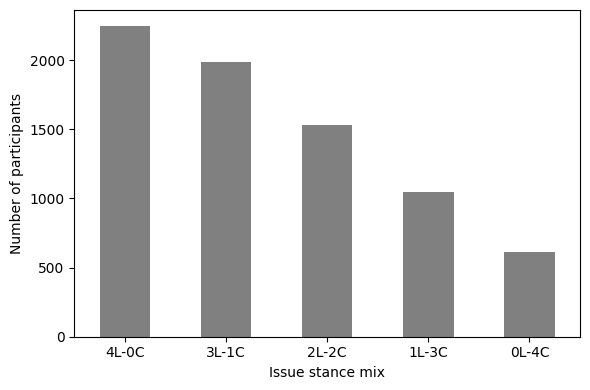

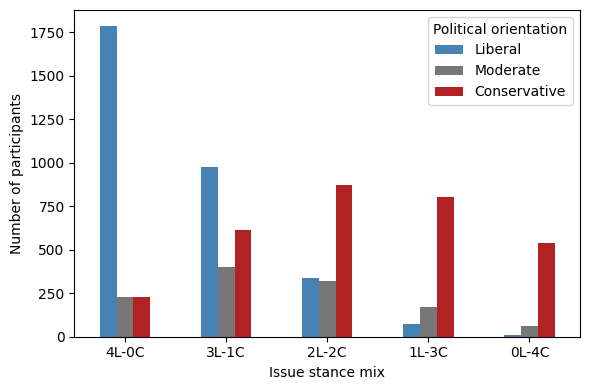

In [30]:
# Plot distribution of stance mixes overall and by political orientation

stance_order = ["4L-0C", "3L-1C", "2L-2C", "1L-3C", "0L-4C"]

def stance_bucket(row):
    return f"{int(row['num_liberal'])}L-{int(row['num_conservative'])}C"

plot_df = count_df_with_politics.copy()
plot_df["stance_bucket"] = plot_df.apply(stance_bucket, axis=1)
plot_df["stance_bucket"] = pd.Categorical(
    plot_df["stance_bucket"],
    categories=stance_order,
    ordered=True,
)

# aggregate histogram
aggregate_counts = (
    plot_df["stance_bucket"]
    .value_counts()
    .reindex(stance_order, fill_value=0)
)


spectrum_order = ["Liberal", "Moderate", "Conservative"]

conditioned_counts = (
    plot_df[plot_df["Political spectrum (us)"].isin(spectrum_order)]
    .groupby(["Political spectrum (us)", "stance_bucket"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=spectrum_order, columns=stance_order, fill_value=0)
)


# Chart 1: All participants
fig1, ax1 = plt.subplots(figsize=(6, 4))
aggregate_counts.plot(kind="bar", ax=ax1, color="gray")
ax1.set_xlabel("Issue stance mix")
ax1.set_ylabel("Number of participants")
ax1.tick_params(axis="x", rotation=0)
plt.tight_layout()
fig1.savefig("../figures/stance-mix-all-participants.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Chart 2: By political orientation
fig2, ax2 = plt.subplots(figsize=(6, 4))
conditioned_counts.T.plot(
    kind="bar",
    ax=ax2,
    color=["steelblue", "#777777", "firebrick"],
)
ax2.set_xlabel("Issue stance mix")
ax2.set_ylabel("Number of participants")
ax2.tick_params(axis="x", rotation=0)
ax2.legend(title="Political orientation")
plt.tight_layout()
fig2.savefig("../figures/stance-mix-by-political-orientation.pdf", dpi=300, bbox_inches="tight")
plt.show()
